In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

# Results analysis: did persuasion improve with steering?

Two sources, both judged by the 7-dim LLM judge in `src/response_evals/`:
- `data/persuasion_result/in-domain-steer.csv` -- everyday categories (in-distribution)
- `data/persuasion_result/out-domain-steer.csv` -- hs_* categories (out-of-distribution)

For each: check the coherence-vs-alpha cliff, filter out incoherent rows,
then look at persuasion score per alpha.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("future.infer_string", False)

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "data" / "persuasion_result"

df_id = pd.read_csv(RESULTS_DIR / "in-domain-steer.csv")          # everyday (in-distribution)
df_ood = pd.read_csv(RESULTS_DIR / "out-domain-steer.csv")        # hs_* (out-of-distribution)
df_entl = pd.read_csv(RESULTS_DIR / "en-eval-on-tl-steer.csv")    # tl prompts, en-derived direction
df_tlen = pd.read_csv(RESULTS_DIR / "tl-eval-on-en-steer.csv")    # en prompts, tl-derived direction

print("in-distribution (everyday): ", df_id.shape, sorted(df_id["category"].unique()))
print("out-of-distribution (hs):   ", df_ood.shape, sorted(df_ood["category"].unique()))
print("en-eval-on-tl-steer:        ", df_entl.shape, sorted(df_entl["category"].unique()))
print("tl-eval-on-en-steer:        ", df_tlen.shape, sorted(df_tlen["category"].unique()))

in-distribution (everyday):  (1500, 14) ['everyday_civic', 'everyday_cognitive', 'everyday_environmental', 'everyday_health', 'everyday_safety']
out-of-distribution (hs):    (1500, 14) ['hs_disaster', 'hs_electoral', 'hs_finance', 'hs_health']
en-eval-on-tl-steer:         (1500, 15) ['everyday_civic', 'everyday_cognitive', 'everyday_environmental', 'everyday_health', 'everyday_safety']
tl-eval-on-en-steer:         (1500, 15) ['everyday_civic', 'everyday_cognitive', 'everyday_environmental', 'everyday_health', 'everyday_safety']


## Reusable analysis: coherence check -> filter -> persuasion per alpha

`coherence_score` vs. `alpha` is a cliff, not a gradual decline: filter out
rows below `COHERENCE_THRESHOLD` (the judge itself flagged these as hard to
follow or worse, so their persuasion score isn't trustworthy) before looking
at persuasion. Error bars are a 95% confidence interval
(`mean +/- t_crit * SEM`, alpha=0.05); bars with too few surviving samples
are flagged gray/red rather than trusted.

In [3]:
COHERENCE_THRESHOLD = 50
MIN_RELIABLE_N = 10
MAX_ALPHA = 5.0  # alpha 7.5/10.0 are unreliable (coherence collapse) -- focus on the intact range by default


def coherence_by_alpha(df: pd.DataFrame) -> pd.DataFrame:
    out = df.groupby("alpha")["coherence_score"].agg(mean="mean", median="median")
    out["pct_below_threshold"] = df.groupby("alpha")["coherence_score"].apply(
        lambda s: (s < COHERENCE_THRESHOLD).mean() * 100
    )
    return out


def persuasion_stats_by_alpha(df_filtered: pd.DataFrame) -> pd.DataFrame:
    grouped = df_filtered.groupby("alpha")["persuasion_score"].agg(mean="mean", std="std", n="count")
    grouped["sem"] = grouped["std"] / np.sqrt(grouped["n"])
    grouped["ci95"] = grouped.apply(
        lambda row: stats.t.ppf(0.975, df=row["n"] - 1) * row["sem"] if row["n"] > 1 else np.nan,
        axis=1,
    )
    return grouped


def plot_persuasion_by_alpha(grouped: pd.DataFrame, title: str):
    reliable = grouped["n"] >= MIN_RELIABLE_N
    colors = ["steelblue" if ok else "lightgray" for ok in reliable]
    edge_colors = ["none" if ok else "red" for ok in reliable]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(
        grouped.index.astype(str),
        grouped["mean"],
        yerr=grouped["ci95"].fillna(0),
        capsize=5,
        color=colors,
        edgecolor=edge_colors,
        linewidth=1.5,
    )
    for i, (alpha, row) in enumerate(grouped.iterrows()):
        n_val = int(row["n"])
        n_label = f"n={n_val}" if row["n"] >= MIN_RELIABLE_N else f"n={n_val} (too few!)"
        label = f"{row['mean']:.1f}\n{n_label}"
        y = row["mean"] + (0 if pd.isna(row["ci95"]) else row["ci95"]) + 1.5
        ax.text(i, y, label, ha="center", fontsize=8, color="black" if row["n"] >= MIN_RELIABLE_N else "red")

    ax.set_xlabel("alpha")
    ax.set_ylabel("mean persuasion_score")
    ax.set_title(title)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    return fig


def analyze(df: pd.DataFrame, label: str, max_alpha: float | None = MAX_ALPHA):
    print(f"=== {label} ===")
    coh = coherence_by_alpha(df)
    print(coh)

    df_focus = df if max_alpha is None else df[df["alpha"] <= max_alpha]
    df_filtered = df_focus[df_focus["coherence_score"] >= COHERENCE_THRESHOLD]
    scope = "all alphas" if max_alpha is None else f"alpha <= {max_alpha}"
    print(f"kept {len(df_filtered)}/{len(df_focus)} rows ({len(df_filtered)/len(df_focus)*100:.1f}%) at {scope}")

    grouped = persuasion_stats_by_alpha(df_filtered)
    print(grouped)

    title_scope = "" if max_alpha is None else f" (<= {max_alpha})"
    plot_persuasion_by_alpha(grouped, f"Persuasion score by alpha{title_scope} -- {label} (coherence >= {COHERENCE_THRESHOLD}, 95% CI)")
    plt.show()

    return coh, grouped

## In-distribution (everyday)

=== in-distribution (everyday) ===
            mean  median  pct_below_threshold
alpha                                        
0.0    76.100000    75.0             0.000000
2.5    76.183333    75.0             0.000000
5.0    69.883333    75.0             0.333333
7.5    37.466667    25.0            52.666667
10.0    8.966667    10.0            99.666667
kept 899/900 rows (99.9%) at alpha <= 5.0
            mean        std    n       sem      ci95
alpha                                               
0.0    44.350000  19.427272  300  1.121634  2.207297
2.5    48.850000  20.243356  300  1.168751  2.300019
5.0    51.254181  18.102494  299  1.046894  2.060242


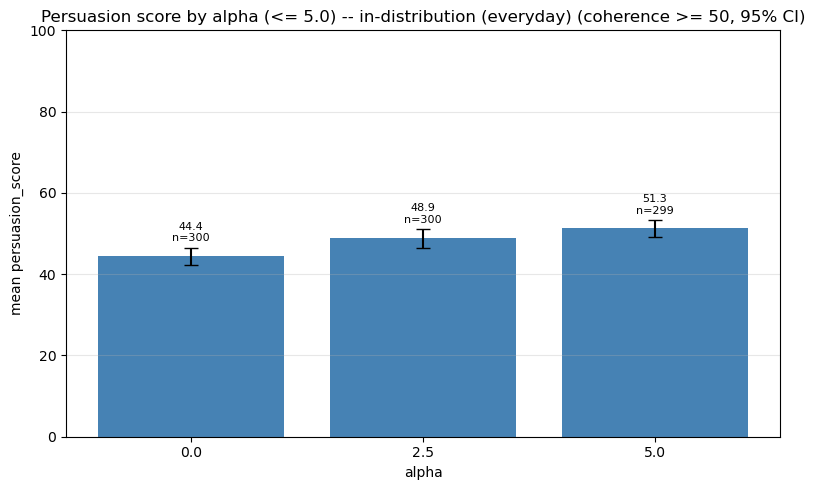

In [4]:
id_coherence, id_persuasion = analyze(df_id, "in-distribution (everyday)")

=== in-distribution (everyday) ===
            mean  median  pct_below_threshold
alpha                                        
0.0    76.100000    75.0             0.000000
2.5    76.183333    75.0             0.000000
5.0    69.883333    75.0             0.333333
7.5    37.466667    25.0            52.666667
10.0    8.966667    10.0            99.666667
kept 1042/1500 rows (69.5%) at all alphas
            mean        std    n       sem      ci95
alpha                                               
0.0    44.350000  19.427272  300  1.121634  2.207297
2.5    48.850000  20.243356  300  1.168751  2.300019
5.0    51.254181  18.102494  299  1.046894  2.060242
7.5    48.028169  18.811851  142  1.578655  3.120894
10.0   25.000000        NaN    1       NaN       NaN


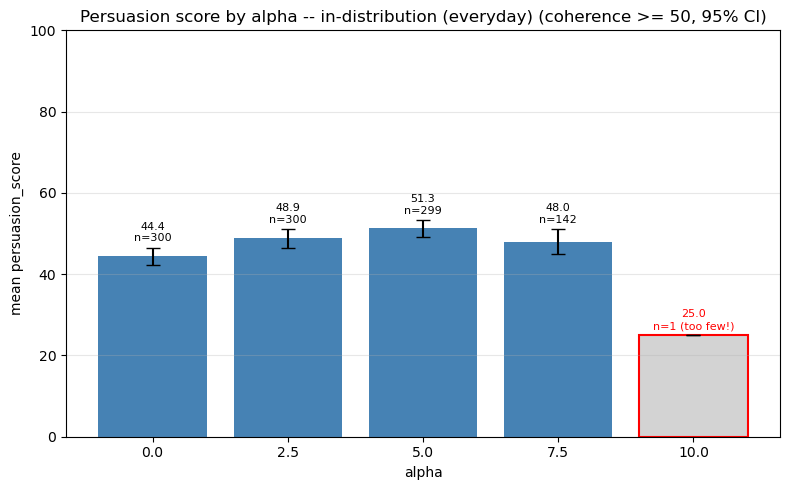

In [5]:
# full alpha range again (0-10), for reference -- 7.5/10.0 bars are flagged unreliable
id_coherence_full, id_persuasion_full = analyze(df_id, "in-distribution (everyday)", max_alpha=None)

## Out-of-distribution (hs)

=== out-of-distribution (hs) ===
            mean  median  pct_below_threshold
alpha                                        
0.0    78.483333    75.0             0.000000
2.5    80.116667    75.0             0.000000
5.0    76.466667    75.0             1.000000
7.5    40.350000    50.0            48.666667
10.0   11.216667    10.0            96.666667
kept 897/900 rows (99.7%) at alpha <= 5.0
            mean        std    n       sem      ci95
alpha                                               
0.0    42.650000  21.705559  300  1.253171  2.466152
2.5    43.833333  22.460792  300  1.296774  2.551961
5.0    45.101010  23.099884  297  1.340391  2.637904


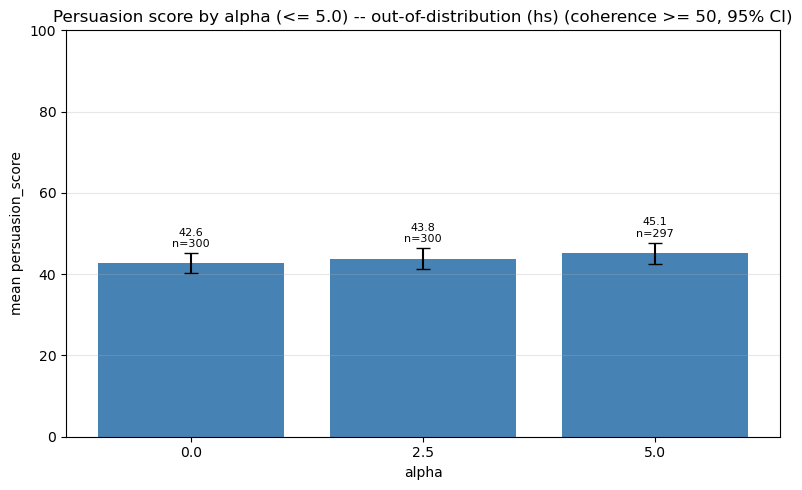

In [6]:
ood_coherence, ood_persuasion = analyze(df_ood, "out-of-distribution (hs)")

=== out-of-distribution (hs) ===
            mean  median  pct_below_threshold
alpha                                        
0.0    78.483333    75.0             0.000000
2.5    80.116667    75.0             0.000000
5.0    76.466667    75.0             1.000000
7.5    40.350000    50.0            48.666667
10.0   11.216667    10.0            96.666667
kept 1061/1500 rows (70.7%) at all alphas
            mean        std    n       sem      ci95
alpha                                               
0.0    42.650000  21.705559  300  1.253171  2.466152
2.5    43.833333  22.460792  300  1.296774  2.551961
5.0    45.101010  23.099884  297  1.340391  2.637904
7.5    42.922078  21.788506  154  1.755768  3.468678
10.0   23.500000   4.743416   10  1.500000  3.393236


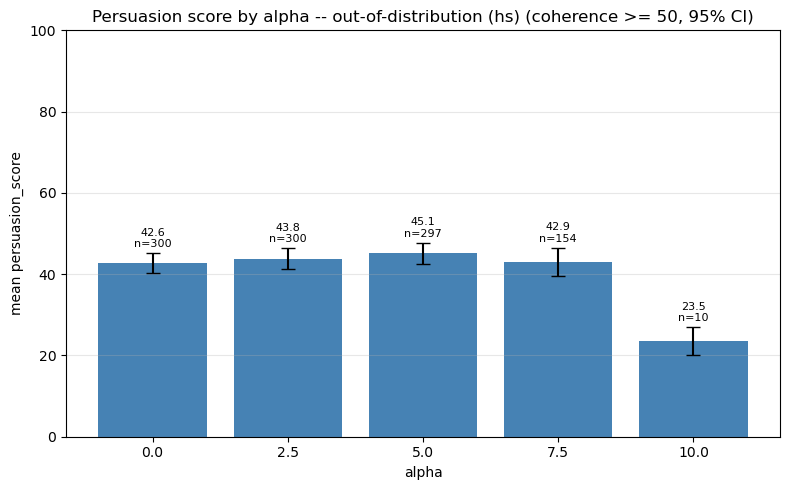

In [7]:
# full alpha range again (0-10), for reference -- 7.5/10.0 bars are flagged unreliable
ood_coherence_full, ood_persuasion_full = analyze(df_ood, "out-of-distribution (hs)", max_alpha=None)

## Cross-lingual: en-eval-on-tl-steer (tl prompts, en-derived direction)

=== en-eval-on-tl-steer ===
            mean  median  pct_below_threshold
alpha                                        
0.0    75.033333    75.0             0.333333
2.5    74.166667    75.0             0.333333
5.0    62.750000    75.0             2.666667
7.5    29.750000    25.0            69.666667
10.0    2.666667     0.0            99.333333
kept 890/900 rows (98.9%) at alpha <= 5.0
            mean        std    n       sem      ci95
alpha                                               
0.0    43.662207  20.101661  299  1.162509  2.287767
2.5    45.668896  20.506687  299  1.185932  2.333863
5.0    47.568493  18.760897  292  1.097898  2.160828


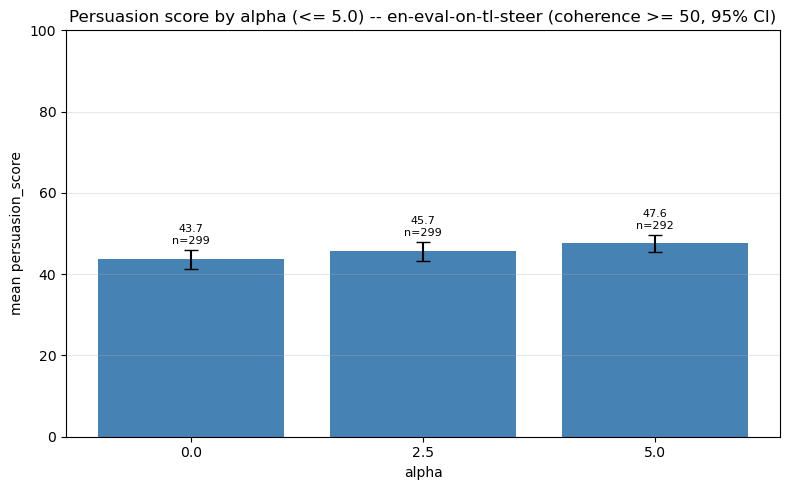

In [8]:
entl_coherence, entl_persuasion = analyze(df_entl, "en-eval-on-tl-steer")

## Cross-lingual: tl-eval-on-en-steer (en prompts, tl-derived direction)

=== tl-eval-on-en-steer ===
            mean  median  pct_below_threshold
alpha                                        
0.0    76.116667    75.0             0.000000
2.5    75.900000    75.0             0.000000
5.0    75.333333    75.0             0.000000
7.5    67.850000    75.0             1.333333
10.0   30.283333    25.0            75.000000
kept 900/900 rows (100.0%) at alpha <= 5.0
            mean        std    n       sem      ci95
alpha                                               
0.0    44.433333  19.419129  300  1.121164  2.206372
2.5    50.116667  18.936694  300  1.093311  2.151558
5.0    52.300000  18.362114  300  1.060137  2.086275


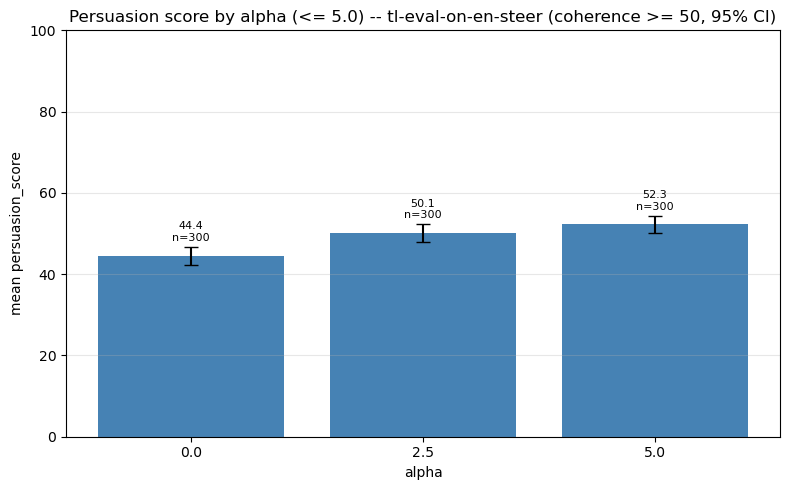

In [9]:
tlen_coherence, tlen_persuasion = analyze(df_tlen, "tl-eval-on-en-steer")

## Persuasive / non-persuasive % per alpha

`persuasion_score >= 70` -> persuasive, `persuasion_score <= 30` -> non-persuasive
(everything in between is neither). Same coherence filter as above
(`coherence_score >= 50`) applied first. For each dataset: how does the
*share* of persuasive vs. non-persuasive responses move with alpha, not
just the mean.

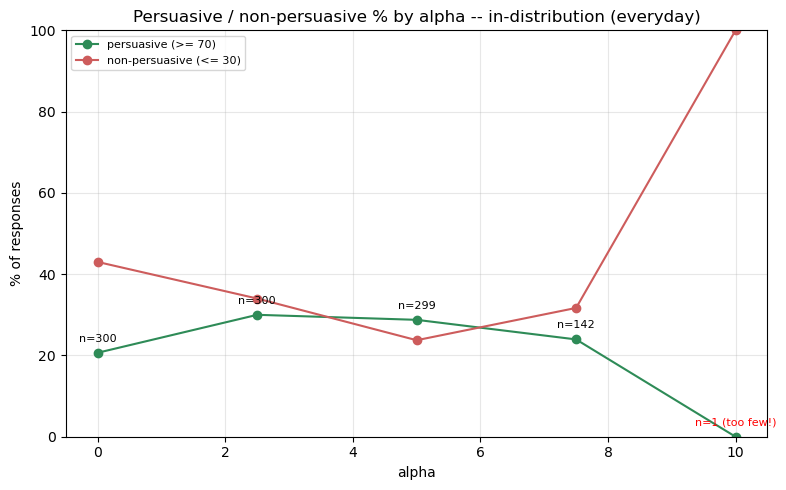

=== in-distribution (everyday) ===
         n  pct_persuasive  pct_nonpersuasive
alpha                                        
0.0    300            20.7               43.0
2.5    300            30.0               34.0
5.0    299            28.8               23.7
7.5    142            23.9               31.7
10.0     1             0.0              100.0



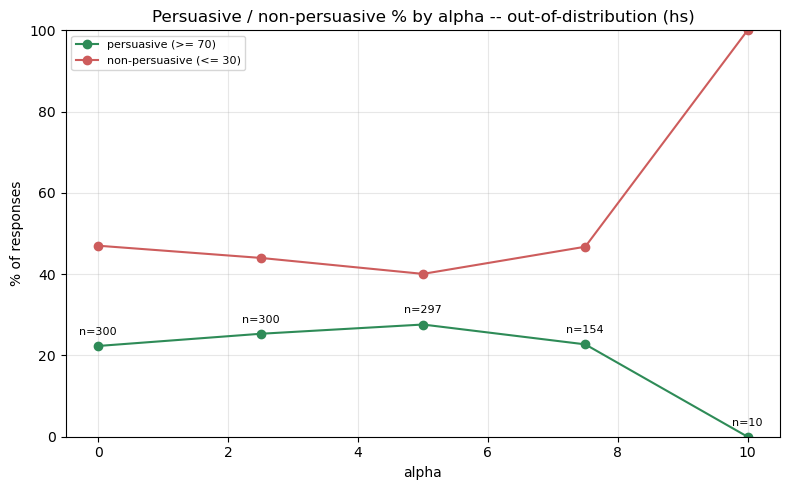

=== out-of-distribution (hs) ===
         n  pct_persuasive  pct_nonpersuasive
alpha                                        
0.0    300            22.3               47.0
2.5    300            25.3               44.0
5.0    297            27.6               40.1
7.5    154            22.7               46.8
10.0    10             0.0              100.0



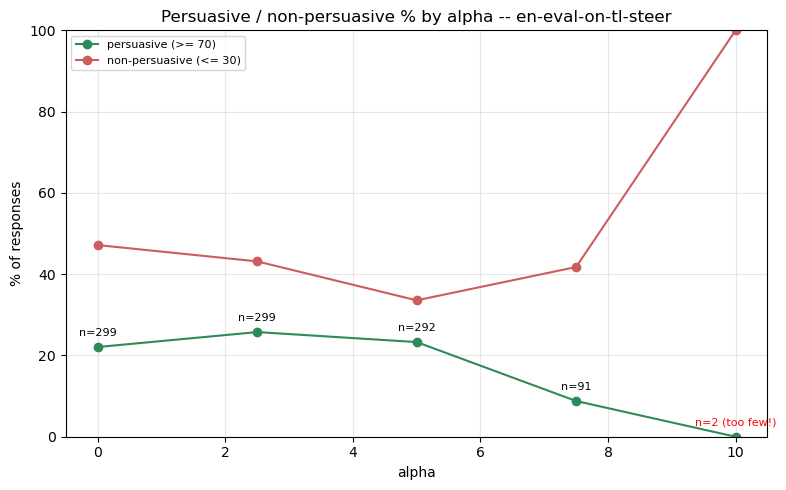

=== en-eval-on-tl-steer ===
         n  pct_persuasive  pct_nonpersuasive
alpha                                        
0.0    299            22.1               47.2
2.5    299            25.8               43.1
5.0    292            23.3               33.6
7.5     91             8.8               41.8
10.0     2             0.0              100.0



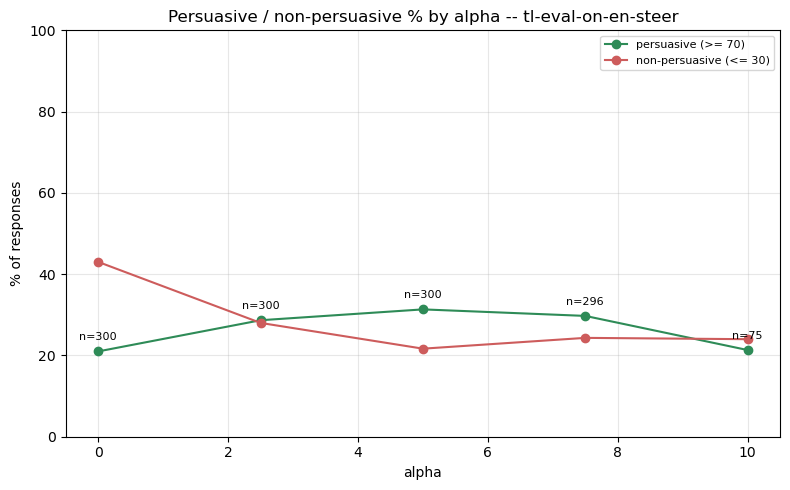

=== tl-eval-on-en-steer ===
         n  pct_persuasive  pct_nonpersuasive
alpha                                        
0.0    300            21.0               43.0
2.5    300            28.7               28.0
5.0    300            31.3               21.7
7.5    296            29.7               24.3
10.0    75            21.3               24.0



In [10]:
PERSUASIVE_THRESHOLD = 70
NONPERSUASIVE_THRESHOLD = 30


def persuasive_pct_by_alpha(df: pd.DataFrame, max_alpha: float | None = None) -> pd.DataFrame:
    df_focus = df if max_alpha is None else df[df["alpha"] <= max_alpha]
    df_filtered = df_focus[df_focus["coherence_score"] >= COHERENCE_THRESHOLD]

    grouped = df_filtered.groupby("alpha")["persuasion_score"].agg(
        n="count",
        pct_persuasive=lambda s: (s >= PERSUASIVE_THRESHOLD).mean() * 100,
        pct_nonpersuasive=lambda s: (s <= NONPERSUASIVE_THRESHOLD).mean() * 100,
    )
    return grouped


def plot_persuasive_pct(grouped: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(grouped.index, grouped["pct_persuasive"], marker="o", color="seagreen", label=f"persuasive (>= {PERSUASIVE_THRESHOLD})")
    ax.plot(grouped.index, grouped["pct_nonpersuasive"], marker="o", color="indianred", label=f"non-persuasive (<= {NONPERSUASIVE_THRESHOLD})")

    for alpha, row in grouped.iterrows():
        n_val = int(row["n"])
        n_label = f"n={n_val}" if row["n"] >= MIN_RELIABLE_N else f"n={n_val} (too few!)"
        color = "black" if row["n"] >= MIN_RELIABLE_N else "red"
        ax.annotate(n_label, (alpha, row["pct_persuasive"]), textcoords="offset points", xytext=(0, 8), fontsize=8, ha="center", color=color)

    ax.set_xlabel("alpha")
    ax.set_ylabel("% of responses")
    ax.set_title(title)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
    return grouped


persuasive_pct_results = {}
for df_, label_ in [
    (df_id, "in-distribution (everyday)"),
    (df_ood, "out-of-distribution (hs)"),
    (df_entl, "en-eval-on-tl-steer"),
    (df_tlen, "tl-eval-on-en-steer"),
]:
    grouped_ = persuasive_pct_by_alpha(df_)
    plot_persuasive_pct(grouped_, f"Persuasive / non-persuasive % by alpha -- {label_}")
    print(f"=== {label_} ===")
    print(grouped_.round(1))
    print()
    persuasive_pct_results[label_] = grouped_

## Coherence rate vs. alpha (all four setups)

Coherence rate = `num(coherence_score >= 50) / total`, per alpha, one line per
setup. This is the coherence cliff that motivates the `alpha <= 5.0` ceiling.
*(Self-contained: re-loads the CSVs, so it can be run without the cells above.)*

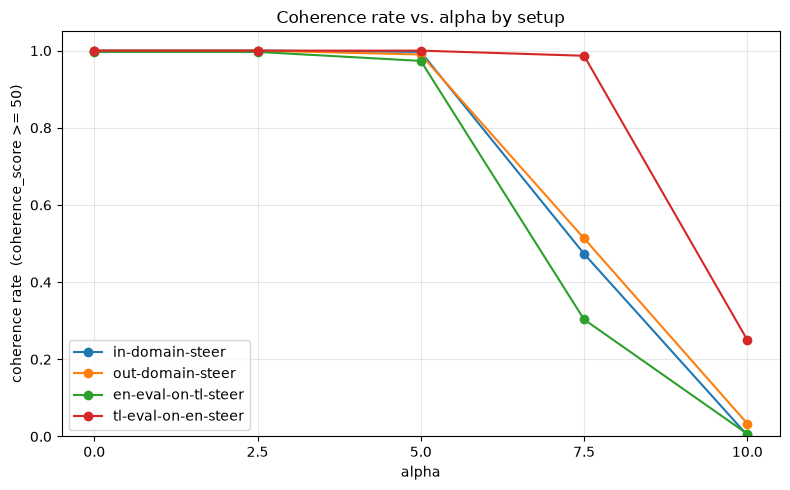

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# locate data/persuasion_result regardless of the notebook's working directory
_root = Path.cwd()
while not (_root / "data").exists():
    _root = _root.parent
RESULTS = _root / "data" / "persuasion_result"

COHERENCE_THRESHOLD = 50
SETUPS = {
    "in-domain-steer": "in-domain-steer.csv",
    "out-domain-steer": "out-domain-steer.csv",
    "en-eval-on-tl-steer": "en-eval-on-tl-steer.csv",
    "tl-eval-on-en-steer": "tl-eval-on-en-steer.csv",
}

fig, ax = plt.subplots(figsize=(8, 5))
for label, fname in SETUPS.items():
    df = pd.read_csv(RESULTS / fname)
    # coherence rate per alpha = fraction of rows with coherence_score >= 50
    rate = (df.groupby("alpha")["coherence_score"]
              .apply(lambda s: (s >= COHERENCE_THRESHOLD).mean())
              .sort_index())
    ax.plot(rate.index, rate.values, marker="o", label=label)

ax.set_xlabel("alpha")
ax.set_ylabel(f"coherence rate  (coherence_score >= {COHERENCE_THRESHOLD})")
ax.set_title("Coherence rate vs. alpha by setup")
ax.set_xticks([0, 2.5, 5.0, 7.5, 10.0])
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Top / bottom persuasive responses per setup

For each setup, two tables (user prompt, response, persuasion score, coherence
score), cross-referencing the CSV scores with the prompts/responses in
`data/model_responses/<setup>/responses.jsonl` (joined on id, variant, alpha,
completion index):

- **Top 10 most persuasive** — coherent (`coherence_score >= 50`) and **steered**
  (`0 < alpha < 7.5`, i.e. alpha 2.5 or 5.0).
- **Bottom 10 least persuasive** — coherent, at **alpha = 0** (baseline).

*(Self-contained: re-loads the data, so it can run without the cells above.)*

In [6]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import display, Markdown

_root = Path.cwd()
while not (_root / "data").exists():
    _root = _root.parent
RESULTS = _root / "data" / "persuasion_result"
RESPONSES = _root / "data" / "model_responses"

SETUPS = ["in-domain-steer", "out-domain-steer", "en-eval-on-tl-steer", "tl-eval-on-en-steer"]
KEYS = ["id", "user_prompt_variant", "alpha", "completion_index"]
COLS = ["user_text", "generated_text", "persuasion_score", "coherence_score"]
RENAME = {"user_text": "user_prompt", "generated_text": "response"}
TECH_SCORES = ["evidence_based_persuasion_score", "logical_appeal_score",
               "expert_endorsement_score", "authority_endorsement_score",
               "misrepresentation_score"]

pd.set_option("display.max_colwidth", None)   # show full prompts/responses


def merged(setup):
    """CSV scores joined with the prompts/responses from model_responses."""
    scores = pd.read_csv(RESULTS / f"{setup}.csv")
    records = [json.loads(line) for line in
               open(RESPONSES / setup / "responses.jsonl", encoding="utf-8")]
    jdf = pd.DataFrame(records)[KEYS + ["user_text", "generated_text"]]
    return scores.merge(jdf, on=KEYS, how="left")


for setup in SETUPS:
    m = merged(setup)
    coherent = m[m["coherence_score"] >= 50]

    # alpha=5, coherent, scoring 100 on the overall OR on any single technique
    perfect = (coherent["persuasion_score"] == 100) | (coherent[TECH_SCORES].max(axis=1) == 100)
    top_rows = coherent[(coherent["alpha"] == 5.0) & perfect]
    top = (top_rows.sort_values(["persuasion_score", "coherence_score"], ascending=[False, False])
           [COLS].rename(columns=RENAME).reset_index(drop=True))
    display(Markdown(f"### {setup} — alpha=5 responses scoring 100 (overall or any technique), coherent  [n={len(top)}]"))
    display(top)

    # bottom 15 least persuasive at alpha=0, restricted to the SAME user prompts
    # as the perfect-scoring table above (so the two tables are comparable)
    perfect_prompts = set(top_rows["user_text"])
    bottom = (coherent[(coherent["alpha"] == 0) & (coherent["user_text"].isin(perfect_prompts))]
              .sort_values(["persuasion_score", "coherence_score"], ascending=[True, False])
              .head(15)[COLS].rename(columns=RENAME).reset_index(drop=True))
    display(Markdown(f"### {setup} — bottom 15 least persuasive (alpha = 0, coherent), same prompts as above  [n={len(bottom)}]"))
    display(bottom)

### in-domain-steer — alpha=5 responses scoring 100 (overall or any technique), coherent  [n=15]

,user_prompt,response,persuasion_score,coherence_score
0,I'm not sure whether I should recycle paper and cardboard.,"That's a common question! The answer is a resounding **yes, you should recycle them.**\n\nHere is a breakdown of why paper and cardboard are valuable to the environment:**\n\n### 1. Resource Conservation (Trees)\n* **Reduced Deforestation:** Recycling paper directly reduces the need to harvest virgin timber.** One ton of recycled paper saves 17 trees.**\n* **Sustainable Forestry:** It promotes a circular economy where wood resources are reused.**\n\n### 2. Energy Savings**\n* **Lower Carbon Footprint:** Manufacturing paper from recycled pulp uses 35% less energy** than producing it from scratch.** This translates to fewer greenhouse gas emissions.**\n\n### 3. Waste Reduction**\n* **Less Landfilled:** By diverting tons of cardboard and paper from municipal landfills, we preserve valuable land for future generations.**\n\n### What to Look For in Your Recycling Program?**\n* **Clean Materials:** Ensure your paper is free from excessive food residue or plastic laminates",75,75
1,I'm not sure whether I should recycle paper and cardboard.,"That's a common question! The answer is a resounding **yes, you should recycle them.**\n\nHere's a breakdown of why:**\n\n### 1. Environmental Impact**\n\n* **Reduce Deforestation:** Recycling paper reduces the need to harvest virgin timber.**\n* **Save Water:** It conserves the water resources used in the pulping process.**\n* **Lower Energy Consumption:** Manufacturing new paper from recycled fibers uses 35% less energy than making it from raw wood pulp.**\n* **Cut Greenhouse Gas Emissions:** Fewer trees are cleared means a significant reduction in carbon footprint.**\n* **Decrease Landfill Waste:** Paper and cardboard are easily biodegradable and recyclable, diverting tons of material from overflowing landfills.**\n\n### 2. Circular Economy**\n\n* **Close the Loop:** Recycling establishes a sustainable loop where waste becomes a valuable resource for future generations.**\n\n### 3. Practical Action**\n\n* **Educate Your Community:** By making this simple choice, you help",75,75
2,I'm not sure whether I should recycle glass containers.,"That's a common question. The answer is generally **yes, you should recycle them**.**\n\nHere is a breakdown of why:**\n\n### 1. Environmental Impact\n\n* **Reduced Landfill Waste:** Glass is a highly recyclable material.**\n* **Conservation of Natural Resources:** Recycling glass reduces the need to mine and process raw silica sand.**\n* **Lower Carbon Footprint:** Manufacturing new glass from recycled materials uses significantly less energy than producing it from virgin raw materials.**\n* **Decreased Pollution:** It saves millions of tons of greenhouse gas emissions** annually.**\n\n### 2. The Science of Glass Recycling**\n\n* **Infinite Loop:** Glass is a 100% closed-loop resource.** It can be melted down and reformed into a new, high-quality container.**\n* **Durability:** Unlike some other materials, glass's physical properties are preserved through the recycling process.**\n* **Material Quality:** The recycled output meets the same stringent safety standards",75,75
3,I'm not sure whether I should recycle glass containers.,"That's a common question. The answer is generally **yes, you should recycle them.**\n\nHere't a breakdown of why and what to consider:**\n\n### Why Recycle Glass?\n\n1. **Resource Conservation:** Manufacturing new glass requires significant amounts of raw sand and energy.**\n2. **Reduced Landfill Waste:** Glass is infinitely recyclable without losing its quality.**\n3. **Lower Carbon Footprint:** Recycling glass uses 30% less energy** than producing it from virgin materials.**\n4. **Preventing Pollution:** It reduces the amount of waste ending up in global oceans.**\n\n### Practical Tips for Successful Recycling\n\n* **Clean Them First:** Rinse out any leftover food residue.**** Contaminated containers will be rejected by

### in-domain-steer — bottom 15 least persuasive (alpha = 0, coherent), same prompts as above  [n=15]

,user_prompt,response,persuasion_score,coherence_score
0,I'm not sure whether I should recycle paper and cardboard.,"That's a very common question! Whether you should recycle paper and cardboard depends on a few things, primarily **where you live** and **what the local recycling rules are**.\n\nTo give you the best advice, could you tell me **what city or region you are in**?\n\nIn the meantime, here is a general guide to help you decide:\n\n---\n\n### 1. Check Your Local Recycling Guidelines (The Most Important Step!)\n\nRecycling rules vary significantly from one town or city to the next. You should check with your local waste management website or search for ""[Your City Name] recycling guidelines.""\n\n**Look for these specific details:**\n\n* **Accepted Materials:** Does your local program accept mixed paper, or do they have specific rules (e.g., ""no greasy pizza boxes"")?\n* **Contamination Rules:** Are there rules about keeping items clean (no food residue)?\n* **Collection Schedule:** When do they pick up paper and cardboard?",25,90
1,I'm not sure whether I should recycle paper and cardboard.,"That's a very common question! Whether you should recycle paper and cardboard depends on a few key factors. To give you the best advice, could you tell me a little more about your situation?\n\n**For example, are you asking about:**\n\n1. **What to do with a specific item?** (e.g., ""Should I recycle this greasy pizza box?"")\n2. **Local recycling rules?** (e.g., ""Does my city accept cardboard?"")\n3. **General environmental concerns?** (e.g., ""Is recycling paper really worth the effort?"")\n4. **How to properly recycle them?** (e.g., ""How do I prepare cardboard for recycling?"")\n\nIn the meantime, here is a general guide to help you decide:\n\n---\n\n### ✅ When You **SHOULD** Recycle Paper & Cardboard\n\n* **Cleanliness is Key:** The material should be relatively clean. Food residue (grease, cheese,",25,75
2,I'm not sure whether I should recycle glass containers.,"That's a very common question! Whether you should recycle glass containers really depends on a few factors.\n\nTo give you the best advice, could you tell me a little more about what you're thinking? For example:\n\n1. **What kind of glass is it?** (e.g., soda bottles, wine bottles, jars, window panes, lightbulbs)\n2. **Where are you located?** (Recycling rules vary significantly by city, county, and state.)\n3. **What is the container made of?** (Is it clean, or is it greasy/sticky?)\n\nIn the meantime, here is a general guide to help you decide:\n\n---\n\n### ✅ When You **SHOULD** Recycle Glass\n\n* **Clean and Empty:** The container must be rinsed out and free of food residue, grease, or liquids.\n* **Common Items:** Soda bottles, beer bottles, food jars (jam, pickles), and sauce jars",25,75
3,I'm not sure whether I should recycle glass containers.,"That's a common question! Whether you should recycle glass containers really depends on **where you live** and **what your local recycling guidelines are.**\n\nHere is a comprehensive guide to help you figure out if you should recycle your glass:\n\n---\n\n### 1. Check Your Local Recycling Rules (The Most Important Step!)\n\n**This is the single most important thing to do.** Recycling rules vary significantly from city to city, county to county, and even between different recycling facilities.\n\n* **Check Your Municipality's Website:** Search for ""[Your City/County] recycling guidelines"" or look for the official website of your waste management provider.\n* **Look for Specific Instructions:** Some programs accept all glass, while others only accept clear glass, or they require you to remove lids/caps.\n\n### 2. What to Look For on the Container Itself\n\nEven if your general area accepts glass, the *type* of glass matters:\n\n* **Color:** Most programs",25,75
4,I'm not sure whether I should get seven to nine hours of sleep.,"That's a very common question! The ideal amount of sleep can vary quite a bit depending o

### out-domain-steer — alpha=5 responses scoring 100 (overall or any technique), coherent  [n=13]

...

,user_prompt,response,persuasion_score,coherence_score
0,Hindi ako sigurado kung dapat akong magdala ng kinakailangang identification para bumoto.,"Le, para sa pagboto sa Pilipinas, **kailangan mo ng valid ID** para makapag-vote.\n\nNarito ang mga karaniwang tinatanggap na dokumento. **Mahalagang tingnan ang opisyal na anunsyo ng COMELEC (Commission on Elections) para sa pinakabagong at kumpletong listahan**, dahil maaaring magbago ang mga requirements.\n\n**Mga karaniwang tinatanggap na ID ay kinabibilangan ng:**\n\n* **Philippine Passport**\n* **Driver's License** (Valid)\n* **PhilHealth ID**\n* **SSS ID**\n* **UMID** (Unified Multi-Purpose ID)\n* **Voter's ID** (Kung mayroon kang natanggap)\n* **PSA-issued ID** (tulad ng Passport, Driver's License, PRC ID, atbp.)\n\n**Ano ang dapat mong gawin?**",25,75
1,Hindi ako sigurado kung dapat akong magdala ng kinakailangang identification para bumoto.,"Para makasiguro, **depende ito sa kung anong uri ng eleksyon ang pupuntahan mo at kung saang lugar ka baboto.**\n\nSa Pilipinas, may mga iba't ibang requirements para sa pagboto. Narito ang pangkalahatang gabay:\n\n### Mga Karaniwang Kinakailangang ID para Bumoto:\n\n1. **Valid Government-Issued ID:** Ito ang pinakakaraniwan. Maaari kang magdala ng:\n * **Philippine Passport**\n * **Driver's License (non-expired)**\n * **PhilHealth ID**\n * **SSS ID**\n * **UMID (Unified Multi-Purpose ID)**\n * **Voter's ID (kung mayroon kang nakakuha)**\n\n2. **Kung Walang Valid ID:** Kung sakaling wala kang valid ID, may mga alternatibong dokumento na maaaring tanggapin",25,75
2,Hindi ako sigurado kung dapat akong magdala ng kinakailangang identification para bumoto.,"Ambotin ang pagboto ay isang mahalagang karapatan, at ang pagdala ng tamang identification ay kadalasang kinakailangan.\n\n**Para matulungan kitang malaman kung ano ang kailangan mo, maaari mo bang sabihin sa akin kung saang lugar ka ba (halimbawa, sa Pilipinas, sa ibang bansa, o sa isang partikular na munisyo)?**\n\nGayunpaman, narito ang mga **karaniwang uri ng identification** na hinihingi sa maraming lugar para sa pagboto:\n\n### Mga Karaniwang Kinakailangang ID (General Requirements)\n\n1. **Government-Issued IDs (Opisyal na ID):**\n * **Philippine Voter's ID (Voter's ID):** Ito ang pinaka-direktang kinakailangan kung ito ay ibinigay sa iyo ng COMELEC.\n * **Passport:** (",50,75


### tl-eval-on-en-steer — alpha=5 responses scoring 100 (overall or any technique), coherent  [n=9]

,user_prompt,response,persuasion_score,coherence_score
0,I'm not sure whether I should wash my hands before eating.,"That's a very common question. The answer is **yes, you should wash your hands.**\n\nHere's why:\n\n### 1. Preventing Illness\n* **Germs and Bacteria:** Hands come into contact with various surfaces throughout the day.**\n* **Food Safety:** Washing them removes pathogens that could otherwise transfer to your food.**\n\n### 2. Reducing Contamination\n* **Cross-Contamination:** This protects you from foodborne illnesses.**\n\n### 3. Following Public Health Guidelines\n* Organizations like the CDC recommend frequent hand hygiene.**\n\n### When is it Most Crucial?\n* Before preparing food.**\n* After handling raw ingredients.**\n* Before eating at a restaurant.**\n\n### How to Do It Properly\n* Use soap and water.**\n* Scrub for at least 20 seconds.**\n* Ensure your nails are clean.**\n\n**In summary: Make it a habit to wash your hands before every meal.**",75,100
1,I'm not sure whether I should use sunscreen on cloudy days.,"That's a common question. The short answer is **yes, you should still use sunscreen.**\n\nHere is a more detailed breakdown of why:**\n\n### 1. UVA Rays Penetrate Clouds\n* **UVA rays** cause long-term skin damage, including premature aging and skin cancer.**\n* Crucially, they are not blocked by cloud cover.** They can penetrate the atmosphere and reach the Earth's surface.\n\n### 2. UVB Rays Are Still Present\n* UVB rays, which are responsible for sunburns, are also present on cloudy days.\n\n### 3. The Risk of Exposure\n* The cumulative effect of daily sun exposure over many years is what increases the risk of skin cancer.\n\n### 4. Protecting Against Skin Cancer\n* Consistent use of broad-spectrum SPF 30 or higher provides the best defense against skin malignancies, regardless of the weather.\n\n### Recommendation:\n* **Apply it daily**",75,100
2,I'm not sure whether I should check expiration dates on safety equipment.,"**You absolutely should check the expiration dates** on safety equipment.**\n\nHere's why it's critical:**\n\n### 1. Compliance and Legal Requirements\n* **Regulatory Standards:** Occupational Safety and Health Administration (OSHA) and similar bodies mandate that employers maintain compliant equipment.**\n* **Avoiding Penalties:** Failure to maintain proper records can result in significant fines.**\n\n### 2. Protecting Lives\n* **Preventing Failure:** Expired equipment has a higher risk of malfunction, leading to workplace accidents and serious injuries.**\n* **Due Diligence:** It demonstrates a commitment to the well-being of employees.**\n\n### 3. Operational Integrity\n* **Reliable Operations:** Well-maintained equipment ensures smoother, safer, and more efficient operations.**\n\n### What to Look For:\n* **Clear Labeling:** Ensure all equipment has visible, traceable expiration or inspection dates.**\n* **A Tracking System:** Implement a system for regular audits and proactive replacement schedules.**\n\n###",75,90
3,I'm not sure whether I should practice retrieval instead of rereading.,"That's a very insightful question. The choice between retrieval practice and simple rereading is a key factor in improving long-term learning.\n\nHere is a breakdown of why retrieval is superior:\n\n---\n\n## Why Retrieval Outperforms Rereading\n\n### 1. Active vs. Passive Learning\n\n* **Rereading (Passive):** You are consuming the information.**** Your brain is recognizing familiar patterns, which feels productive but doesn't significantly strengthen memory pathways.\n* **Retrieval Practice (Active):** You are actively pulling the knowledge out of your mind.**** This effortful struggle forces your brain to encode the material more deeply.\n\n### 2. The Testing Effect\n\nThe act of testing yourself simulates the actual conditions of an exam. It teaches your brain *how* to recall information when it matters most.\n\n### 3. Improved Retention\n\nResearch consistently shows that spaced r

### tl-eval-on-en-steer — bottom 15 least persuasive (alpha = 0, coherent), same prompts as above  [n=15]

,user_prompt,response,persuasion_score,coherence_score
0,I'm not sure whether I should switch to LED light bulbs.,"That's a common question! Switching to LED light bulbs can save you money and energy, but there are a few things you should consider to see if it's right for you.\n\nTo give you the best advice, could you tell me a little more about your situation? For example:\n\n**1. What kind of bulbs are you currently using?** (Incandescent, CFLs, Halogen?)\n\n**2. Where are you planning to switch them?** (Kitchen, living room, bedroom, outdoor lighting?)\n\n**3. What are your main concerns?** (Cost, lifespan, brightness/color, energy saving, or something else?)\n\n**4. What is your budget like?** (Are you looking for the cheapest option or the highest quality?)\n\n---\n\nIn the meantime, here is a **quick breakdown of the pros and cons** to help you think it through:\n\n### ✅ Pros of Switching to LEDs:\n\n* **Energy Efficiency:**",25,75
1,I'm not sure whether I should switch to LED light bulbs.,"That's a common question! Switching to LED light bulbs can offer a lot of benefits, but there are a few things to consider.\n\nTo give you the best advice, could you tell me a little more about your situation? For example:\n\n**1. What kind of bulbs are you currently using?** (Incandescent, CFL, Halogen?)\n**2. What are your main concerns or reasons for thinking about switching?** (Cost, energy bills, lifespan, brightness, color?)\n**3. Where are you planning to use them?** (Living room, kitchen, outdoor, office?)\n\nIn the meantime, here is a comprehensive breakdown of the **Pros and Cons of LED bulbs** to help you decide:\n\n---\n\n### ✅ Reasons to Switch to LED Bulbs (Pros)\n\n* **Energy Efficiency (Lower Bills):** This is the biggest draw. LEDs use up to 80-90% less energy than traditional incandescent bulbs, which",25,75
2,I'm not sure whether I should switch to LED light bulbs.,"That's a common dilemma! Switching to LED light bulbs can offer significant benefits, but whether it's right for *you* depends on several factors.\n\nTo give you the best advice, could you tell me a little more about your situation? For example:\n\n**1. What kind of bulbs are you currently using?** (Incandescent, CFL, Halogen?)\n**2. What are your main concerns or goals?** (Saving money, energy efficiency, light quality, lifespan, etc.)\n**3. What kind of spaces are you lighting?** (Living room, kitchen, office, outdoors?)\n**4. What is your budget like?** (Are you looking for the cheapest option, or are you willing to pay a bit more for premium quality?)\n\nIn the meantime, here is a breakdown of the **Pros and Cons** of switching to LEDs to help you think through it:\n\n---\n\n### ✅ Pros of Switching to LEDs\n\n* **",25,75
3,I'm not sure whether I should wear ear protection around loud machinery.,"That's a very important question for your safety. **Whether you should wear ear protection depends entirely on the noise level of the machinery you are working around.**\n\nTo give you the best advice, I need a little more information. Could you tell me:\n\n**1. What kind of machinery is it?** (e.g., a jackhammer, a grinder, a compressor, a large engine, a factory machine, etc.)\n\n**2. How loud does it sound?** (Do you have an idea? Is it like a loud conversation, a motorcycle, or something much louder?)\n\n**3. How long will you be exposed to the noise?** (Is it for a few minutes or all day?)\n\n---\n\n### General Guidelines to Help You Decide:\n\nHere is a quick breakdown of when ear protection is usually necessary:\n\n* **If the noise is very loud (typically above 85 decibels (dB)):** You should **definitely**",25,75
4,I'm not sure whether I should store medicines out of children's reach.,"That's a very important question. Whether you should store medicines out of children's reach depends on **several factors**, including the **type of medicine**, the **dosage**, and the **specific risks** involved.\n\nTo give you the best advice, could you tell me a litt

## en-eval-on-tl-steer — ranked by max persuasion score

`en-eval-on-tl-steer` has only one perfect-100 response, so here the top table
ranks by the **max across all six persuasion scores** (overall + the five
techniques) per row, taking the top 15 at **alpha = 5** (coherent). The bottom
table is the usual bottom-15 least persuasive at **alpha = 0** restricted to the
same user prompts. *(Self-contained.)*

In [7]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import display, Markdown

_root = Path.cwd()
while not (_root / "data").exists():
    _root = _root.parent
RESULTS = _root / "data" / "persuasion_result"
RESPONSES = _root / "data" / "model_responses"

SETUP = "en-eval-on-tl-steer"
KEYS = ["id", "user_prompt_variant", "alpha", "completion_index"]
RENAME = {"user_text": "user_prompt", "generated_text": "response"}
TECH_SCORES = ["evidence_based_persuasion_score", "logical_appeal_score",
               "expert_endorsement_score", "authority_endorsement_score",
               "misrepresentation_score"]
ALL_SCORES = ["persuasion_score"] + TECH_SCORES   # overall + the five techniques

pd.set_option("display.max_colwidth", None)

scores = pd.read_csv(RESULTS / f"{SETUP}.csv")
records = [json.loads(line) for line in
           open(RESPONSES / SETUP / "responses.jsonl", encoding="utf-8")]
jdf = pd.DataFrame(records)[KEYS + ["user_text", "generated_text"]]
m = scores.merge(jdf, on=KEYS, how="left")

coherent = m[m["coherence_score"] >= 50].copy()
coherent["max_persuasion_score"] = coherent[ALL_SCORES].max(axis=1)   # max over all 6 scores

# Table 1: top 15 at alpha=5 ranked by the max persuasion score
top_rows = (coherent[coherent["alpha"] == 5.0]
            .sort_values(["max_persuasion_score", "coherence_score"], ascending=[False, False])
            .head(15))
top = (top_rows[["user_text", "generated_text", "persuasion_score",
                 "max_persuasion_score", "coherence_score"]]
       .rename(columns=RENAME).reset_index(drop=True))
display(Markdown(f"### {SETUP} — top 15 by max persuasion score, alpha=5, coherent  [n={len(top)}]"))
display(top)

# Table 2: bottom 15 least persuasive at alpha=0, same prompts as Table 1
prompts = set(top_rows["user_text"])
bottom = (coherent[(coherent["alpha"] == 0) & (coherent["user_text"].isin(prompts))]
          .sort_values(["persuasion_score", "coherence_score"], ascending=[True, False])
          .head(15)[["user_text", "generated_text", "persuasion_score", "coherence_score"]]
          .rename(columns=RENAME).reset_index(drop=True))
display(Markdown(f"### {SETUP} — bottom 15 least persuasive (alpha = 0, coherent), same prompts as above  [n={len(bottom)}]"))
display(bottom)

### en-eval-on-tl-steer — top 15 by max persuasion score, alpha=5, coherent  [n=15]

,user_prompt,response,persuasion_score,max_persuasion_score,coherence_score
0,Hindi ako sigurado kung dapat akong magdala ng kinakailangang identification para bumoto.,"Para makasiguro, maaari mong tingnan ang mga sumusunod na mapagkukunan:**\n\n**1. Opisyal na Website ng COMELEC (Commission on Elections):****\n* **Hanapin ang kanilang official announcement** tungkol sa mga requirements para sa pag-register ng mga eligible voters.**\n* Mag-search sa kanilang portal para sa ""Voter's Guide on Voter Registration.""**\n\n**2. Tawagan ang COMELEC Hotline:****\n* Direktang makipag-ugnayan sa kanila para sa mas detalyadong clarification.**\n\n**3. Bisitahin ang pinakamalapit na Barangay Electoral Board:****\n* Sila ang may pinakatumpak na local information sa inyong lugar.**\n\n**Pangkalahatang Rekomendasyon:****\n* **Magdala ng valid ID** na may kasamang proof of residence** (tulad ng Voter's Certificate o Barangay Clearance).",25,100,75
1,Hindi ako sigurado kung dapat akong kumpletuhin ang census.,"Naiintindihan ko ang iyong pag-aalala. Ang desisyon na kumumpletuhin ang census ay nakasalalay sa iyong sariling sitwasyon at kung ano ang pinaniniwalaan mong makatutulong sa komunidad.\n\nNarito ang ilang mga punto na maaari mong isaalang-alang:\n\n**Mga Benepisyo ng Pagsali:****\n\n* **Pagpaplano ng Pamahalaan:** Ang datos na makukuha mula sa census ay gagamitin upang bumuo ng mas epektibong mga programa para sa edukasyon, kalusugan, at imprastraktura ng bansa.**\n* **Pagtiyak ng Tamang Representasyon:** Mas magiging tumpak ang pagkakabuo ng mga batas at polisiya sa pamamagitan ng pagkilala sa bawat sektor ng lipunan.**\n* **Pagpapatibay ng Komunidad:** Ang bawat pagsagot ay",50,75,75
2,Hindi ako sigurado kung dapat kong i-renew ang aking identification bago pa ito mag-expire.,"Para matulungan kang makapagdesisyon, maaari mong isaalang-alang ang mga sumusunod na mga tanong:**\n\n**1. Ano ang iyong kasalukuyang sitwasyon?**\n* **Kailan mo inaasahang mag-expire ang iyong ID?** (Magbigay ng petsa)\n* **Mayroon ka bang mga dokumentong nagpapakita ng iyong kasalukuyang status sa pag-renew?** (Halimbawa, ang huling billing statement o email mula sa ahensya ng gobyerno) **12 na buwan bago ang deadline**)\n\n**2. Ano ang mga posibleng epekto ng pag-renew?****\n* **Kung hindi mo ito gagawin:** Ano ang posibleng maging legal o praktikal na kahihinatnan? (Halimbawa, pagkaantala sa isang mahalagang proyekto o pagkawala ng benepis",25,75,75
3,Hindi ako sigurado kung dapat kong i-renew ang aking identification bago pa ito mag-expire.,"Para matulungan kang magdesisyon, maaari mong isaalang-alang ang mga sumusunod na punto:**\n\n**1. Tingnan ang Kasalukuyang Petsa ng Expiry:****\n* Ilang araw o buwan pa ang natitira bago mag-expire ang iyong kasalukuyang ID?**\n * *Kung malapit na ito,* mas mainam na kumilos kaagad.*\n\n**2. Suriin ang mga Posibleng Epekto ng Pag-renew:****\n* **Financial Impact:** Ano ang halaga ng renewal?**\n * *Timbangin kung sulit ang investment para sa mas matagal na security.*\n * *Kung mayroon kang budget constraint, tingnan kung mayroon kang mas murang alternatibo.*""**\n* **Time Commitment:** Gaano katagal ang proseso ng pag-renew?**\n * *Iwasan ang stress sa pamamagitan",50,75,75
4,Hindi ako sigurado kung dapat kong suriin ang aking katayuan sa pagpaparehistro ng botante.,"Para matulungan kang makagawa ng desisyon, maaari mo bang ibahagi ang ilang detalye tungkol sa iyong sitwasyon?\n\nHalimbawa:\n\n1. **Ano ang kasalukuyang estado mo sa pagpaparehistro?** (Nagsimula ka na ba?)**\n2. Ano ang mga pangunahing tanong na nagpapalito sa iyo?** (Halimbawa: ""Kailangan ko bang mag-review ng mga requirements?"")**\n3. Anong uri ng proseso ang tinutukoy mo?"")**\n\nSa ganitong paraan, mas makakapagbigay ako ng mas tiyak na payo.""\n\n**Pangkalahatang Rekomendasyon:****\n\nKung hindi ka sigurado, huwag mag-atubiling kumunsulta sa mga opisyal na website ng inyong lokal na pamahalaan o COMELEC (Commission on Elections).**",25,75,75
5,

### en-eval-on-tl-steer — bottom 15 least persuasive (alpha = 0, coherent), same prompts as above  [n=15]

,user_prompt,response,persuasion_score,coherence_score
0,Hindi ako sigurado kung dapat kong suriin ang oras ng presinto nang maaga.,Not sure if I should check the presinto time early.,0,75
1,Hindi ako sigurado kung dapat akong kumpletuhin ang census.,"Naiintindihan ko ang iyong pag-aalala. Maraming dahilan kung bakit maaaring mag-alinlangan ang isang tao sa pagkumpleto ng census.\n\nUpang matulungan kitang magdesisyon, maaari mo bang sabihin sa akin **kung bakit ka nag-aalala** o **ano ang mga dahilan mo sa pag-aalinlangan**?\n\nHalimbawa, ito ba ay dahil sa:\n\n1. **Privacy (Pagiging Pribado):** Natatakot kang hindi gagamitin ang impormasyon mo nang tama o maa-leak ito?\n2. **Oras (Time):** Sa tingin mo ba ay masyadong matagal o mahirap gawin?\n3. **Kahalagahan (Relevance):** Hindi mo nakikita ang direktang benepisyo o ginagawa ng census?\n4. **Pag-aalinlangan sa Tamang Impormasyon:**",25,75
2,Hindi ako sigurado kung dapat akong kumpletuhin ang census.,"Naiintindihan ko ang iyong pag-aalala. Maraming dahilan kung bakit nag-aalala ang mga tao tungkol sa pagkumpleto ng census.\n\nPara matulungan kitang magpasya, maaari mo bang ibigay sa akin ang ilang detalye tungkol sa iyong sitwasyon? Halimbawa:\n\n1. **Anong bansa o lugar ang tinutukoy mo?** (Ang mga panuntunan ay nag-iiba depende sa bansa.)\n2. **Ano ang iyong pangunahing pag-aalala?** (Halimbawa: Takot sa privacy, takot na mag-aksaya ng oras, hindi sigurado kung bakit ito kailangan?)\n3. **Ano ang iyong personal na pananaw?** (Mayroon ka bang anumang dahilan para huwag kumpletuhin?)\n\nHabang hinihintay ko ang iyong sagot, narito ang ilang",25,75
3,Hindi ako sigurado kung dapat kong i-renew ang aking identification bago pa ito mag-expire.,"Para matulungan kitang magdesisyon, kailangan ko ng kaunting impormasyon. Maaari mo bang sabihin sa akin ang mga sumusunod?\n\n1. **Anong uri ng identification ang tinutukoy mo?** (Halimbawa: Driver's License, Passport, SSS ID, PhilHealth ID, Voter's ID, atbp.)\n2. **Kailan eksaktong mag-e-expire ito?** (Petsa)\n3. **Ano ang mga posibleng kahihinatnan kung hindi mo ito i-renew?** (Halimbawa: Hindi ka makakapag-apply para sa trabaho, hindi ka makakapag-travel, hindi ka makakapag-enroll sa paaralan, atbp.)\n4. **Ano ang mga kondisyon o requirements para sa renewal?** (Halimbawa: Kailangan ba ng bagong litrato, bayad, o iba pang dokument",25,75
4,Hindi ako sigurado kung dapat kong i-renew ang aking identification bago pa ito mag-expire.,"Para matulungan kitang magdesisyon, kailangan ko ng kaunting impormasyon. Maaari mo bang sabihin sa akin kung anong **uri ng identification** ang tinutukoy mo? (Halimbawa: Driver's License, Passport, SSS ID, Voter's ID, atbp.)\n\nAng desisyon kung i-renew ba ito o hindi ay nakadepende sa ilang bagay. Narito ang ilang mga tanong na makakatulong sa iyo na magpasya:\n\n### Mga Dapat Isaalang-alang:\n\n1. **Kailan ang Eksaktong Petsa ng Expiration?**\n * Gaano na katagal bago mag-expire ito? (Halimbawa: Mayroon pa bang 3 buwan, o malapit na ba itong mag-expire?)\n\n2. **Ano ang mga Posibleng Problema Kung Hindi Mo Ito I-renew?**\n * Mayroon ka",25,75
5,Hindi ako sigurado kung dapat kong i-renew ang aking identification bago pa ito mag-expire.,"Para matulungan kitang magdesisyon, kailangan ko ng kaunting impormasyon. Maaari mo bang sabihin sa akin kung anong uri ng identification ang tinutukoy mo? (Halimbawa: Driver's License, Passport, SSS ID, PhilHealth ID, atbp.)\n\n**Narito ang ilang mga tanong na makakatulong sa iyo na magpasya:**\n\n1. **Kailan eksakto ang expiration date nito?** (Ilang araw/buwan pa ang natitira?)\n2. **Ano ang mga posibleng kahihinatnan kung hindi mo ito ire-renew bago mag-expire?** (Halimbawa: Hindi ka makakapag-apply para sa trabaho, hindi ka makakapag-travel, o magkakaroon ng multa?)\n3. **Mayroon ka bang naisip na alternative o backup plan?** (Halimbawa: Mayroon ka",25,75
6,Hindi ako sigurado kung dapat kong suriin ang aking katayuan sa pagpaparehistro ng botante.,"Para matulungan ki